# Full Pipeline — Training, Evaluation & Visualisation (Improved Method)

This notebook runs the **latest improved pipeline** end-to-end:

1. **Load data** and basic EDA
2. **Load OOF artifacts** (from 05, 06, 07) and **ensemble** (08): correlation matrix, base AUCs, stacking meta-model (C=0.05), 4 or 6 features when ESM is used
3. **Calibration** (09): isotonic regression, reliability diagram, Brier scores
4. **Retrain** base models on full data (including ESM when available)
5. **Submission**: build test stack (4 or 6 cols), meta-predict, calibrate, save CSV
6. **Evaluation & visualisation**: OOF AUC summary, ROC curve, calibration plot

**Prerequisites:** Run notebooks 01 → 02 → 04 → 05 → (06 if ESM) → 07 → 08 so that `data/processed/` contains OOF CSVs, feature matrices, `train_clusters.csv`, and `final_meta_model.pkl`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

plt.style.use('dark_background')
sns.set_palette('viridis')
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load data & EDA

Train: 7143 samples, 2 classes
Test:  1917 samples
Class balance (train): {-1: np.int64(3591), 1: np.int64(3552)}


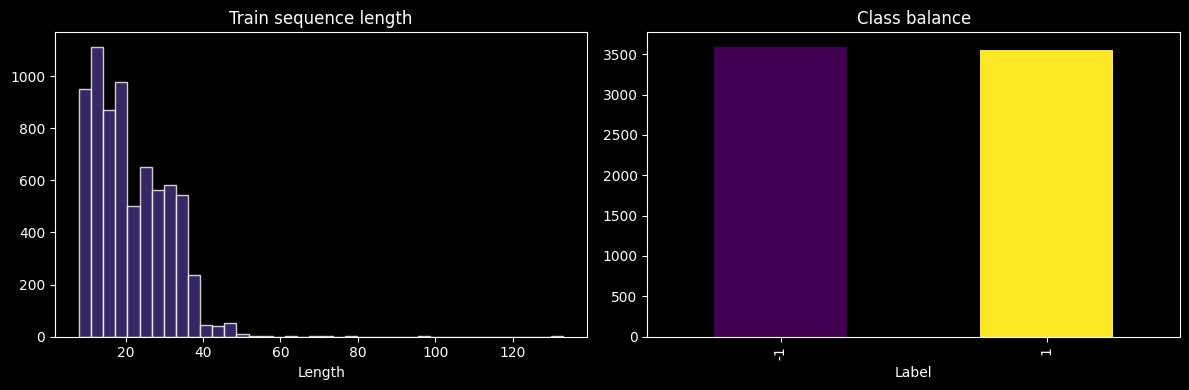

In [2]:
# Load processed train/test
train_df = pd.read_csv('../data/processed/train_clusters.csv')
test_df = pd.read_csv('../data/processed/test_clean.csv')
y_true = train_df['Label'].values
y_mapped = np.where(y_true == 1, 1, 0)
cluster_labels = train_df['Cluster'].values

print(f'Train: {train_df.shape[0]} samples, {train_df["Label"].nunique()} classes')
print(f'Test:  {test_df.shape[0]} samples')
print(f'Class balance (train): {dict(train_df["Label"].value_counts())}')

# Sequence length distribution
lens = train_df['Sequence'].str.len()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(lens, bins=40, edgecolor='white', alpha=0.8)
ax[0].set_title('Train sequence length')
ax[0].set_xlabel('Length')
train_df['Label'].value_counts().plot(kind='bar', ax=ax[1], color=['#440154', '#fde725'])
ax[1].set_title('Class balance')
plt.tight_layout()
plt.show()

## 2. Load OOF & Ensemble (08)

In [3]:
# Load OOF predictions
oof_dfs = []
model_aucs = {}
if os.path.exists('../data/processed/oof_tfidf.csv'):
    df_tfidf = pd.read_csv('../data/processed/oof_tfidf.csv')
    oof_dfs.append(df_tfidf.drop(columns=['Sequence', 'Label']))
    model_aucs['TF-IDF LogReg'] = roc_auc_score(y_true, df_tfidf['tfidf_lr_pred'])
    model_aucs['TF-IDF SVM']    = roc_auc_score(y_true, df_tfidf['tfidf_svm_pred'])
if os.path.exists('../data/processed/oof_tuned_trees.csv'):
    df_trees = pd.read_csv('../data/processed/oof_tuned_trees.csv')
    oof_dfs.append(df_trees.drop(columns=['Sequence', 'Label']))
    model_aucs['Tuned LGBM']    = roc_auc_score(y_true, df_trees['tuned_lgb_pred'])
    model_aucs['Tuned XGBoost'] = roc_auc_score(y_true, df_trees['tuned_xgb_pred'])
use_esm = os.path.exists('../data/processed/oof_esm.csv')
if use_esm:
    df_esm = pd.read_csv('../data/processed/oof_esm.csv')
    oof_dfs.append(df_esm[['esm_lr_pred', 'esm_mlp_pred']])
    model_aucs['ESM2 LogReg'] = roc_auc_score(y_true, df_esm['esm_lr_pred'])
    model_aucs['ESM2 MLP']    = roc_auc_score(y_true, df_esm['esm_mlp_pred'])

oof_all = pd.concat(oof_dfs, axis=1)
print(f'Combined OOF shape: {oof_all.shape}')
print('Base model AUCs:')
for name, score in sorted(model_aucs.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:<15}: {score:.4f}')

Combined OOF shape: (7143, 6)
Base model AUCs:
  Tuned XGBoost  : 0.8941
  Tuned LGBM     : 0.8931
  ESM2 MLP       : 0.8853
  TF-IDF LogReg  : 0.8792
  ESM2 LogReg    : 0.8775
  TF-IDF SVM     : 0.8724


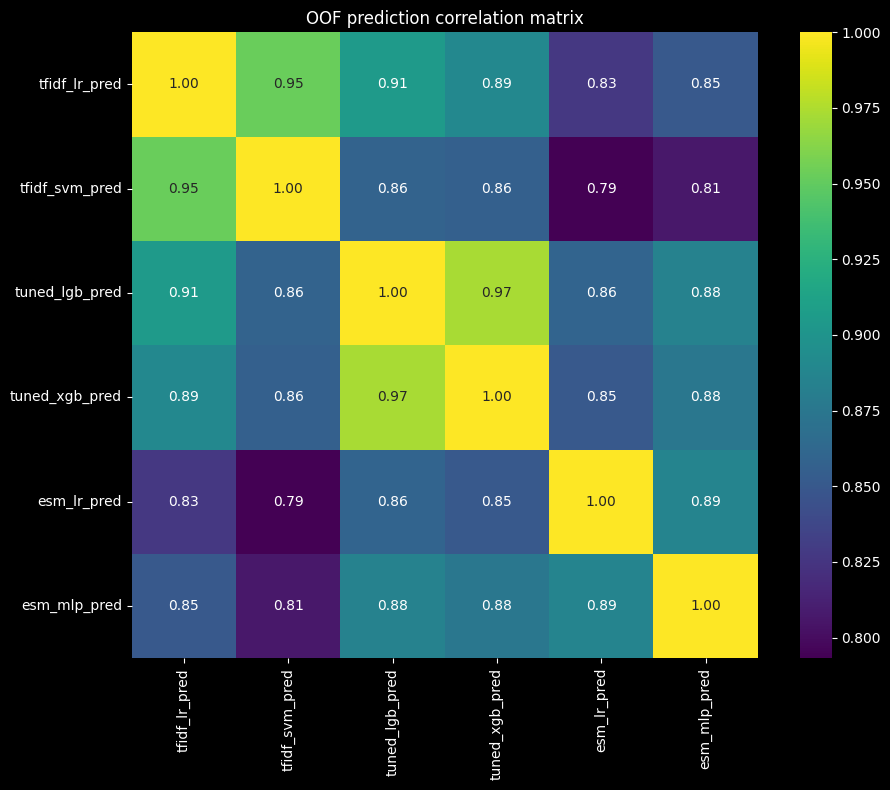

In [4]:
# Correlation matrix of OOF predictions
corr = oof_all.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', ax=ax, square=True)
ax.set_title('OOF prediction correlation matrix')
plt.tight_layout()
plt.show()

In [5]:
# Load or recompute meta-model (same as 08: C=0.05)
X_meta = oof_all.values
meta_path = '../data/processed/final_meta_model.pkl'
if os.path.exists(meta_path):
    meta_model = pd.read_pickle(meta_path)
    print(f'Loaded meta-model from {meta_path}')
else:
    meta_model = LogisticRegression(max_iter=1000, random_state=42, C=0.05, n_jobs=-1)
    meta_model.fit(X_meta, y_mapped)
    pd.to_pickle(meta_model, meta_path)
    print(f'Saved {X_meta.shape[1]}-feature meta-model to {meta_path}')

stack_auc = roc_auc_score(y_true, meta_model.predict_proba(X_meta)[:, 1])
print(f'Stacking OOF AUC: {stack_auc:.4f}')

Loaded meta-model from ../data/processed/final_meta_model.pkl
Stacking OOF AUC: 0.9048


## 3. Calibration (09)

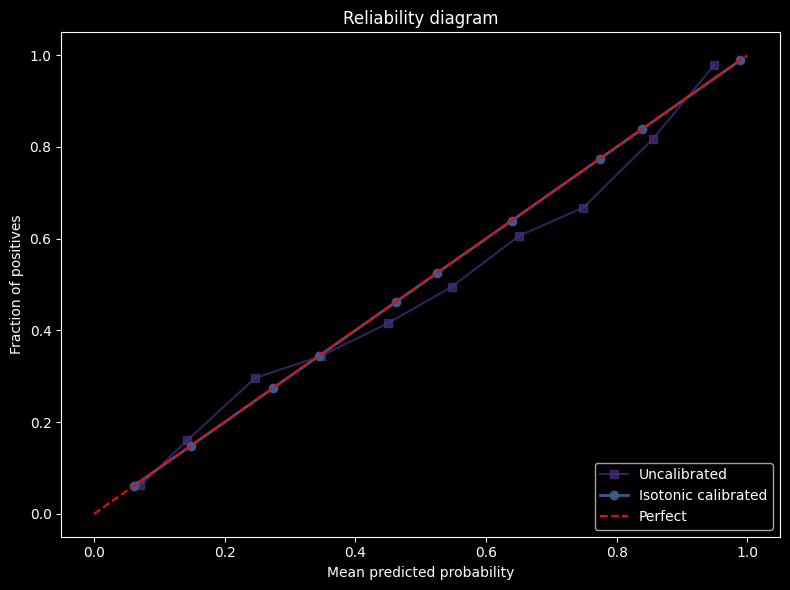

Brier (uncalibrated): 0.1239
Brier (calibrated):   0.1214


In [6]:
raw_ensemble_probs = meta_model.predict_proba(X_meta)[:, 1]
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrated_probs = calibrator.fit_transform(raw_ensemble_probs, y_mapped)

fig, ax = plt.subplots(figsize=(8, 6))
fp, mp = calibration_curve(y_mapped, raw_ensemble_probs, n_bins=10)
ax.plot(mp, fp, 's-', label='Uncalibrated', alpha=0.7)
fp_c, mp_c = calibration_curve(y_mapped, calibrated_probs, n_bins=10)
ax.plot(mp_c, fp_c, 'o-', label='Isotonic calibrated', linewidth=2)
ax.plot([0, 1], [0, 1], 'r--', label='Perfect')
ax.set_title('Reliability diagram')
ax.set_ylabel('Fraction of positives')
ax.set_xlabel('Mean predicted probability')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f'Brier (uncalibrated): {brier_score_loss(y_mapped, raw_ensemble_probs):.4f}')
print(f'Brier (calibrated):   {brier_score_loss(y_mapped, calibrated_probs):.4f}')

## 4. Retrain base models on full data & build test stack

In [7]:
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

X_train_dense = pd.read_pickle('../data/processed/X_train_features.pkl')
X_test_dense  = pd.read_pickle('../data/processed/X_test_features.pkl')
X_train_sparse = sp.load_npz('../data/processed/X_train_tfidf.npz')
X_test_sparse  = sp.load_npz('../data/processed/X_test_tfidf.npz')

# TF-IDF LR & SVM
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, n_jobs=-1)
lr_tfidf.fit(X_train_sparse, y_true)
test_tfidf_lr = lr_tfidf.predict_proba(X_test_sparse)[:, 1]
svm_base = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, random_state=42, n_jobs=-1, max_iter=1000)
svm_cal = CalibratedClassifierCV(estimator=svm_base, method='sigmoid', cv=3)
svm_cal.fit(X_train_sparse, y_true)
test_tfidf_svm = svm_cal.predict_proba(X_test_sparse)[:, 1]

# Trees
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.04, max_depth=6, num_leaves=35, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
lgb.fit(X_train_dense, y_true)
test_lgb = lgb.predict_proba(X_test_dense)[:, 1]
xgb = XGBClassifier(n_estimators=300, learning_rate=0.04, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric='auc', random_state=42, n_jobs=-1)
xgb.fit(X_train_dense, y_mapped)
test_xgb = xgb.predict_proba(X_test_dense)[:, 1]

test_esm_lr = test_esm_mlp = None
if use_esm and os.path.exists('../data/processed/X_train_esm.npy'):
    X_train_esm = np.load('../data/processed/X_train_esm.npy')
    X_test_esm = np.load('../data/processed/X_test_esm.npy')
    esm_lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1, n_jobs=-1)
    esm_lr.fit(X_train_esm, y_true)
    test_esm_lr = esm_lr.predict_proba(X_test_esm)[:, 1]
    esm_mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam', alpha=1e-4, batch_size=64, learning_rate_init=1e-3, max_iter=200, random_state=42)
    esm_mlp.fit(X_train_esm, y_true)
    test_esm_mlp = esm_mlp.predict_proba(X_test_esm)[:, 1]
    print('ESM LR & MLP retrained')
print('Base models retrained on full data.')

ESM LR & MLP retrained
Base models retrained on full data.


In [8]:
# Build test meta matrix (4 or 6 cols)
cols = ['tfidf_lr', 'tfidf_svm', 'tuned_lgb', 'tuned_xgb']
X_test_meta_list = [test_tfidf_lr, test_tfidf_svm, test_lgb, test_xgb]
if use_esm and test_esm_lr is not None and test_esm_mlp is not None:
    cols.extend(['esm_lr', 'esm_mlp'])
    X_test_meta_list.extend([test_esm_lr, test_esm_mlp])
X_test_meta = np.column_stack(X_test_meta_list)
print(f'X_test_meta shape: {X_test_meta.shape}')

X_test_meta shape: (1917, 6)


## 5. Meta-predict, calibrate & save submission

In [17]:
raw_test_probs = meta_model.predict_proba(X_test_meta)[:, 1]
test_calibrated = calibrator.transform(raw_test_probs)

# Build submission to match Data/sample.csv: "# ID", Label (values 1 or -1)
os.makedirs('../submissions', exist_ok=True)
labels = np.where(test_calibrated >= 0.5, 1, -1).astype(int)
sub = pd.DataFrame({
    '# ID': test_df['ID'].values,
    'Label': labels
})
sub.to_csv('../submissions/ensemble_v1.csv', index=False)
print(f'Saved submission: ../submissions/ensemble_v1.csv ({len(sub)} rows)')

Saved submission: ../submissions/ensemble_v1.csv (1917 rows)


In [ ]:
# Also save a probabilities version (same header, Label = calibrated probability)
proba_sub = pd.DataFrame({
    '# ID': test_df['ID'].values,
    'Label': test_calibrated
})
proba_sub.to_csv('../submissions/ensemble_v1_proba.csv', index=False)
print(f'Saved probability submission: ../submissions/ensemble_v1_proba.csv ({len(proba_sub)} rows)')

## 6. Evaluation & visualisation

In [18]:
print('=== OOF AUC summary ===')
for name, score in sorted(model_aucs.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:<15}: {score:.4f}')
print(f'  Stacked (raw)  : {stack_auc:.4f}')
print(f'  Stacked (cal.) : {roc_auc_score(y_true, calibrated_probs):.4f}')

=== OOF AUC summary ===
  Tuned XGBoost  : 0.8941
  Tuned LGBM     : 0.8931
  ESM2 MLP       : 0.8853
  TF-IDF LogReg  : 0.8792
  ESM2 LogReg    : 0.8775
  TF-IDF SVM     : 0.8724
  Stacked (raw)  : 0.9048
  Stacked (cal.) : 0.9061


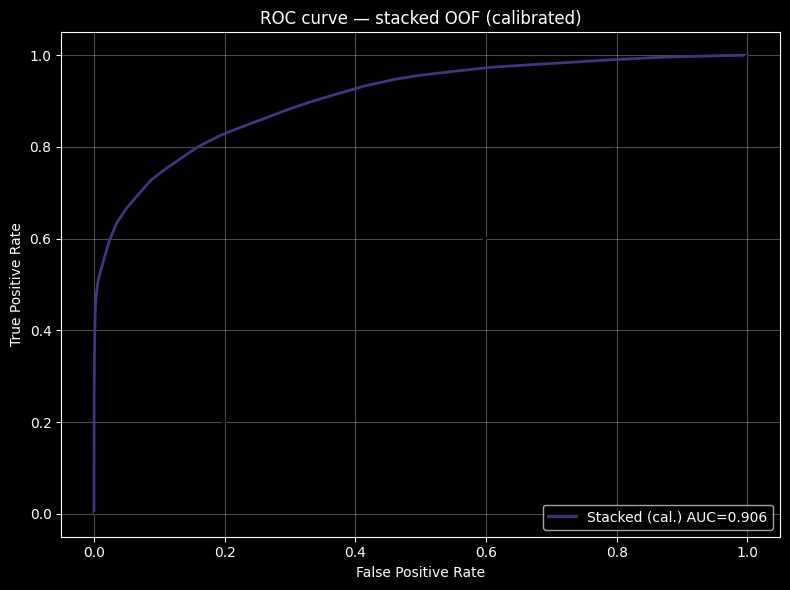

In [19]:
fpr, tpr, _ = roc_curve(y_mapped, calibrated_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacked (cal.) AUC={roc_auc_score(y_mapped, calibrated_probs):.3f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve — stacked OOF (calibrated)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Submission preview
print(sub.head(10))
print()
print('Prediction stats:')
print(sub['Label'].describe())

    # ID  Label
0  10001      1
1  10002      1
2  10003     -1
3  10004     -1
4  10005     -1
5  10006      1
6  10007      1
7  10008     -1
8  10009     -1
9  10010     -1

Prediction stats:
count    1917.000000
mean       -0.200835
std         0.979881
min        -1.000000
25%        -1.000000
50%        -1.000000
75%         1.000000
max         1.000000
Name: Label, dtype: float64
